# PV–Renewable Ninja–SCADA Energy System Analysis

## 1. Objective

This notebook integrates operational SCADA data with simulated solar photovoltaic (PV) potential from Renewable Ninja in order to:

- Evaluate real-time system operation (PV, load, battery, diesel generation)
- Compare actual PV output against weather-driven PV potential
- Estimate renewable energy curtailment (unused solar potential)
- Validate system-level energy balance consistency
- Assess battery dispatch behaviour and flexibility

---

## 2. Data Sources

### 2.1 SCADA / Plant Operational Data (15-minute resolution)

The system dataset contains:
- PV actual power output (kW)
- Load demand (kW)
- Battery Energy Storage System (BESS) power (kW)
- Diesel generator (DG) output (kW)

This represents **real operational behaviour of the energy system**.

---

### 2.2 Renewable Ninja PV Data (Hourly resolution)

Renewable Ninja provides simulated PV generation based on:
- Solar irradiance
- Temperature
- Weather reanalysis datasets
- System configuration assumptions

The output represents a **theoretical PV generation profile under given weather conditions**.

---

## 3. Key Assumptions

### 3.1 Temporal alignment
- SCADA data is aggregated from 15-minute to hourly resolution
- Renewable Ninja data is used at native hourly resolution

This ensures consistency and avoids interpolation bias.

---

### 3.2 PV potential scaling
Renewable Ninja output is assumed to be a normalised PV generation profile.

PV potential is computed as:

PV_potential = (Renewable Ninja output) × (installed PV capacity)

An installed capacity of 3000 kW is actual system capacity

---

### 3.3 Battery sign convention
- Negative BESS values represent charging (energy absorption)
- Positive BESS values represent discharging (energy supply)

---

### 3.4 Energy balance representation
The system is approximated as:

PV + DG + BESS ≈ Load

Any deviation reflects modelling simplifications or unobserved grid exchanges.

---

### 3.5 Curtailment definition
Curtailment is defined as:

Curtailment = PV_potential − PV_actual

where negative values are clipped to zero.

This represents unused renewable generation due to system constraints.

---

## 4. Methodological Workflow

1. Load and clean SCADA dataset  
2. Aggregate SCADA data to hourly resolution  
3. Load and clean Renewable Ninja dataset  
4. Convert Ninja output to PV potential using installed capacity  
5. Merge datasets on hourly timestamps  
6. Perform data quality checks:
   - PV feasibility (PV_actual ≤ PV_potential)
   - Energy balance consistency
   - Battery sign validation  
7. Compute curtailment and utilisation metrics  
8. Generate system-level visualisations  
9. Export processed dataset for further analysis  

---

## 5. Outputs Produced

The notebook generates:

- Hourly system operation profiles
- PV potential vs actual comparison
- Curtailment time series
- Battery charging/discharging behaviour
- Data quality diagnostics
- Clean merged dataset for downstream analysis

---

## 6. Important Note

Results are sensitive to:
- Installed PV capacity assumption
- Renewable Ninja scaling interpretation
- Time aggregation method
- System measurement accuracy

All findings should therefore be interpreted as **model-informed estimates rather than direct measurements of physical losses**.

/var/folders/g3/t0kvm7d92yz4d6h3xvq1x1bw0000gn/T/ipykernel_26085/1235208125.py:33: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H")



Ninja Data Summary:
count    8760.000000
mean        0.143254
std         0.217568
min         0.000000
25%         0.000000
50%         0.000000
75%         0.243250
max         0.843000
Name: pv_potential_raw, dtype: float64

=== DATA QUALITY REPORT ===
PV violations (actual > potential): 1149
Energy balance mean error: -3.9229475884466565
Energy balance std error: 57.32381365816385


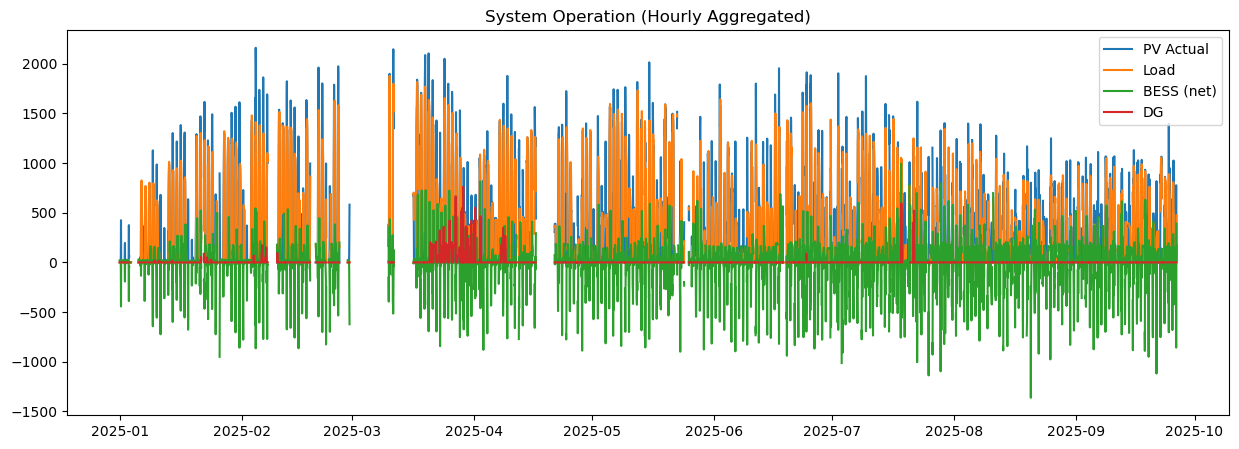

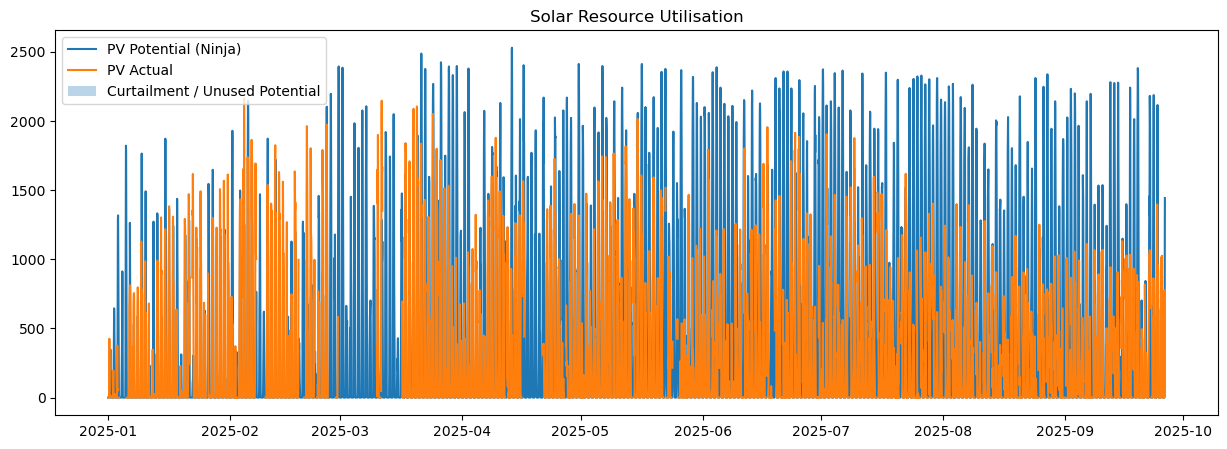

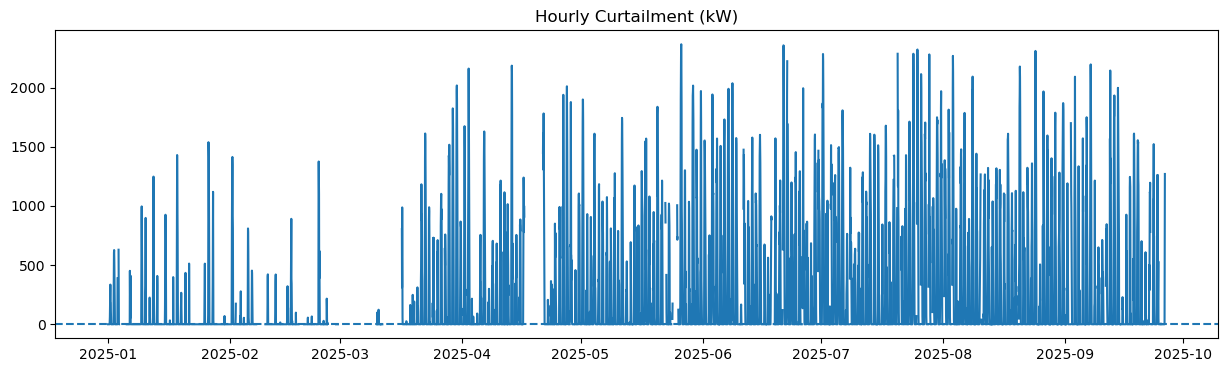

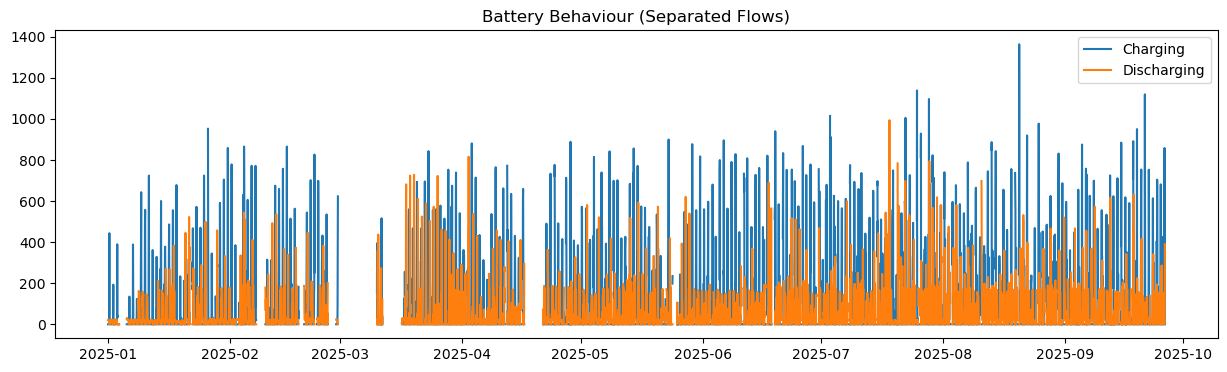


Exported: clean_hourly_energy_analysis.csv


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. LOAD SYSTEM DATA (15-min SCADA)
# =========================================================

system_df = pd.read_csv("Abuja Site.csv")

system_df["date"] = pd.to_datetime(system_df["date"], dayfirst=True)

system_df = system_df.rename(columns={
    "POC PV - Power (PV Meter)": "pv_actual",
    "POC Loads - Power (Loads Meter)": "load",
    "POC BESS - Power (BESS Meter)": "bess",
    "POC DG - Power (DG Meter)": "dg"
})

# Ensure numeric
for col in ["pv_actual", "load", "bess", "dg"]:
    system_df[col] = pd.to_numeric(system_df[col], errors="coerce")

system_df = system_df.sort_values("date")

# =========================================================
# 2. AGGREGATE SYSTEM DATA TO HOURLY (CRITICAL STEP)
# =========================================================

system_hourly = (
    system_df
    .set_index("date")
    .resample("1H")
    .mean()
    .reset_index()
)

# =========================================================
# 3. LOAD RENEWABLE NINJA DATA (HOURLY)
# =========================================================

ninja_df = pd.read_csv(
    "ninja_abuja.csv",
    comment="#",
    sep=None,
    engine="python"
)

ninja_df.columns = ninja_df.columns.str.strip()

ninja_df["time"] = pd.to_datetime(ninja_df["time"])

ninja_df = ninja_df.rename(columns={
    "electricity": "pv_potential_raw"
})

ninja_df = ninja_df.sort_values("time")

# =========================================================
# 4. DETERMINE NINJA DATA TYPE (AUTO CHECK)
# =========================================================

print("\nNinja Data Summary:")
print(ninja_df["pv_potential_raw"].describe())

# =========================================================
# 5. SCALING ASSUMPTION (ONLY IF REQUIRED)
# =========================================================

PV_CAPACITY_KW = 3000  #actual capacity of the system

ninja_df["pv_potential_kw"] = ninja_df["pv_potential_raw"] * PV_CAPACITY_KW

# =========================================================
# 6. MERGE HOURLY DATASETS (SAFE JOIN)
# =========================================================

merged = pd.merge(
    system_hourly,
    ninja_df[["time", "pv_potential_kw"]],
    left_on="date",
    right_on="time",
    how="inner"
)

# =========================================================
# 7. DATA QUALITY CHECKS
# =========================================================

# 7.1 PV feasibility check
merged["pv_violation"] = merged["pv_actual"] - merged["pv_potential_kw"]

# 7.2 Energy balance check
merged["energy_balance"] = (
    merged["pv_actual"]
    + merged["dg"]
    + merged["bess"]
    - merged["load"]
)

print("\n=== DATA QUALITY REPORT ===")
print("PV violations (actual > potential):",
      (merged["pv_violation"] > 0).sum())

print("Energy balance mean error:",
      merged["energy_balance"].mean())

print("Energy balance std error:",
      merged["energy_balance"].std())

# =========================================================
# 8. FIX BESS SIGN FOR INTERPRETABILITY
# =========================================================

merged["bess_charge"] = merged["bess"].clip(upper=0) * -1
merged["bess_discharge"] = merged["bess"].clip(lower=0)

# =========================================================
# 9. CURTAILMENT (ONLY VALID AFTER QA)
# =========================================================

merged["curtailment_kw"] = (
    merged["pv_potential_kw"] - merged["pv_actual"]
)

merged["curtailment_kw"] = merged["curtailment_kw"].clip(lower=0)

merged["curtailment_kwh"] = merged["curtailment_kw"] * 1  # hourly data

# =========================================================
# 10. UTILISATION RATIO
# =========================================================

merged["utilisation_ratio"] = (
    merged["pv_actual"] / merged["pv_potential_kw"]
)

merged["utilisation_ratio"] = merged["utilisation_ratio"].replace(
    [np.inf, -np.inf], 0
).fillna(0)

# =========================================================
# 11. PLOT 1 — SYSTEM OPERATION (REALITY)
# =========================================================

plt.figure(figsize=(15,5))

plt.plot(merged["date"], merged["pv_actual"], label="PV Actual")
plt.plot(merged["date"], merged["load"], label="Load")
plt.plot(merged["date"], merged["bess"], label="BESS (net)")
plt.plot(merged["date"], merged["dg"], label="DG")

plt.title("System Operation (Hourly Aggregated)")
plt.legend()
plt.grid(False)
plt.show()

# =========================================================
# 12. PLOT 2 — PV POTENTIAL vs ACTUAL
# =========================================================

plt.figure(figsize=(15,5))

plt.plot(merged["date"], merged["pv_potential_kw"], label="PV Potential (Ninja)")
plt.plot(merged["date"], merged["pv_actual"], label="PV Actual")

plt.fill_between(
    merged["date"],
    merged["pv_actual"],
    merged["pv_potential_kw"],
    where=merged["pv_potential_kw"] > merged["pv_actual"],
    alpha=0.3,
    label="Curtailment / Unused Potential"
)

plt.title("Solar Resource Utilisation")
plt.legend()
plt.grid(False)
plt.show()

# =========================================================
# 13. PLOT 3 — CURTAILMENT
# =========================================================

plt.figure(figsize=(15,4))

plt.plot(merged["date"], merged["curtailment_kw"])
plt.axhline(0, linestyle="--")

plt.title("Hourly Curtailment (kW)")
plt.grid(False)
plt.show()

# =========================================================
# 14. PLOT 4 — BESS DISPATCH SEPARATED
# =========================================================

plt.figure(figsize=(15,4))

plt.plot(merged["date"], merged["bess_charge"], label="Charging")
plt.plot(merged["date"], merged["bess_discharge"], label="Discharging")

plt.title("Battery Behaviour (Separated Flows)")
plt.legend()
plt.grid(False)
plt.show()

# =========================================================
# 15. EXPORT CLEAN RESULTS
# =========================================================

merged.to_csv("clean_hourly_energy_analysis.csv", index=False)

print("\nExported: clean_hourly_energy_analysis.csv")

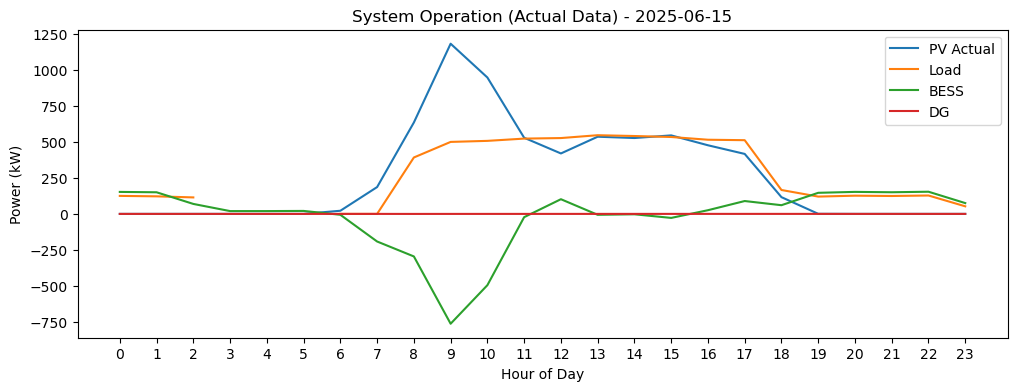

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure datetime
system_hourly["date"] = pd.to_datetime(system_hourly["date"])

test_day = "2025-06-15"

system_day = system_hourly[
    system_hourly["date"].dt.date == pd.Timestamp(test_day).date()
].copy()

system_day["hour"] = system_day["date"].dt.hour

plt.figure(figsize=(12,4))

plt.plot(
    system_day["hour"],
    system_day["pv_actual"],
    label="PV Actual"
)

plt.plot(
    system_day["hour"],
    system_day["load"],
    label="Load"
)

plt.plot(
    system_day["hour"],
    system_day["bess"],
    label="BESS"
)

plt.plot(
    system_day["hour"],
    system_day["dg"],
    label="DG"
)

plt.xticks(range(0,24))
plt.xlabel("Hour of Day")
plt.ylabel("Power (kW)")
plt.title(f"System Operation (Actual Data) - {test_day}")
plt.grid(False)
plt.legend()

plt.show()

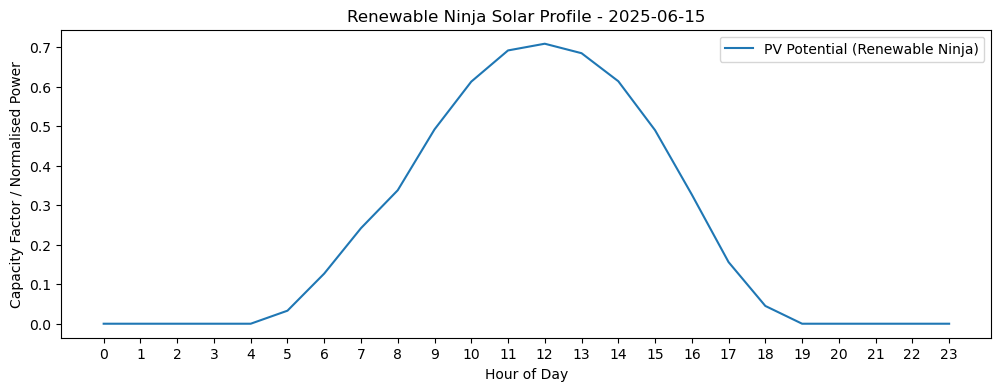

In [38]:
ninja_df["local_time"] = pd.to_datetime(ninja_df["local_time"])

ninja_day = ninja_df[
    ninja_df["local_time"].dt.date == pd.Timestamp(test_day).date()
].copy()

ninja_day["hour"] = ninja_day["local_time"].dt.hour

plt.figure(figsize=(12,4))

plt.plot(
    ninja_day["hour"],
    ninja_day["pv_potential_raw"],
    label="PV Potential (Renewable Ninja)"
)

plt.xticks(range(0,24))
plt.xlabel("Hour of Day")
plt.ylabel("Capacity Factor / Normalised Power")
plt.title(f"Renewable Ninja Solar Profile - {test_day}")
plt.grid(False)
plt.legend()

plt.show()

In [46]:
# =========================================================
# 16. SIMPLE ENERGY WASTE KPI (ROBUST VERSION)
# =========================================================

# Always recompute to avoid missing column errors
curtailment = (merged["pv_potential_kw"] - merged["pv_actual"]).clip(lower=0)

total_potential_energy = merged["pv_potential_kw"].sum()
total_actual_energy = merged["pv_actual"].sum()
total_unused_energy = curtailment.sum()

if total_potential_energy > 0:
    wasted_energy_pct = (total_unused_energy / total_potential_energy) * 100
    utilised_energy_pct = (total_actual_energy / total_potential_energy) * 100
else:
    wasted_energy_pct = 0
    utilised_energy_pct = 0

print("\n================ SIMPLE ENERGY SUMMARY ================")
print(f"Total Solar Potential: {total_potential_energy:,.2f} kWh")
print(f"Total Solar Used     : {total_actual_energy:,.2f} kWh")
print(f"Total Solar Curtailed: {total_unused_energy:,.2f} kWh")

print("\n--- SIMPLE KPI ---")
print(f"✔ Utilised Energy: {utilised_energy_pct:.1f}%")
print(f"✖ Wasted Energy  : {wasted_energy_pct:.1f}%")
print("======================================================")


================ SIMPLE ENERGY SUMMARY ================
Total Solar Potential: 3,088,950.00 kWh
Total Solar Used     : 1,615,885.43 kWh
Total Solar Curtailed: 1,423,449.98 kWh

--- SIMPLE KPI ---
✔ Utilised Energy: 52.3%
✖ Wasted Energy  : 46.1%


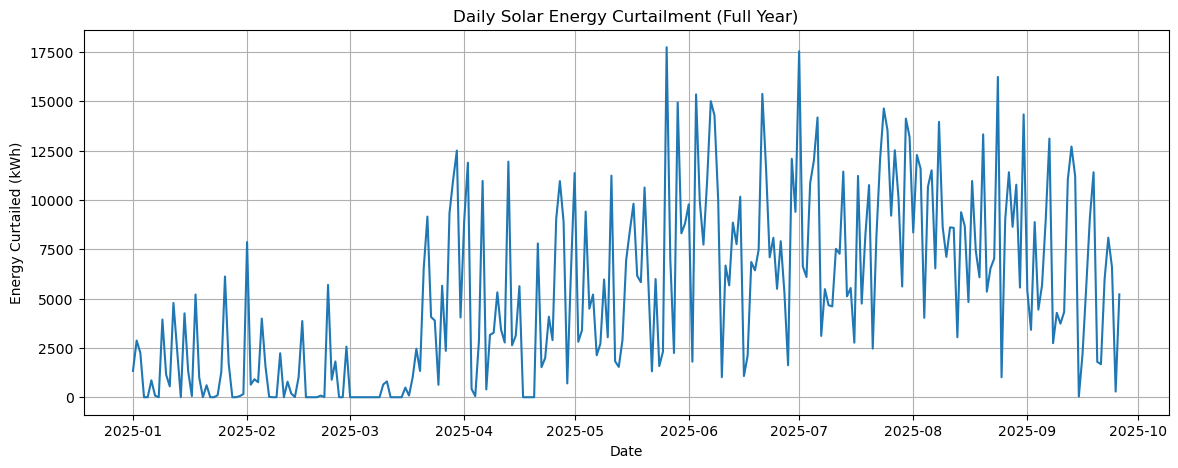

In [50]:
import matplotlib.pyplot as plt

# =========================================================
# RECOMPUTE CURTAILMENT (robust)
# =========================================================

curtailment = (merged["pv_potential_kw"] - merged["pv_actual"]).clip(lower=0)

merged["curtailment_kw"] = curtailment

# =========================================================
# OPTIONAL: AGGREGATE DAILY (MAKES YEAR PLOT CLEANER)
# =========================================================

daily_curtailment = merged.groupby(
    merged["date"].dt.date
)["curtailment_kw"].sum().reset_index()

daily_curtailment.columns = ["date", "curtailment_kwh"]

daily_curtailment["date"] = pd.to_datetime(daily_curtailment["date"])

# =========================================================
# PLOT FULL YEAR TREND
# =========================================================

plt.figure(figsize=(14,5))

plt.plot(
    daily_curtailment["date"],
    daily_curtailment["curtailment_kwh"],
    linewidth=1.5
)

plt.title("Daily Solar Energy Curtailment (Full Year)")
plt.xlabel("Date")
plt.ylabel("Energy Curtailed (kWh)")
plt.grid(True)

plt.show()

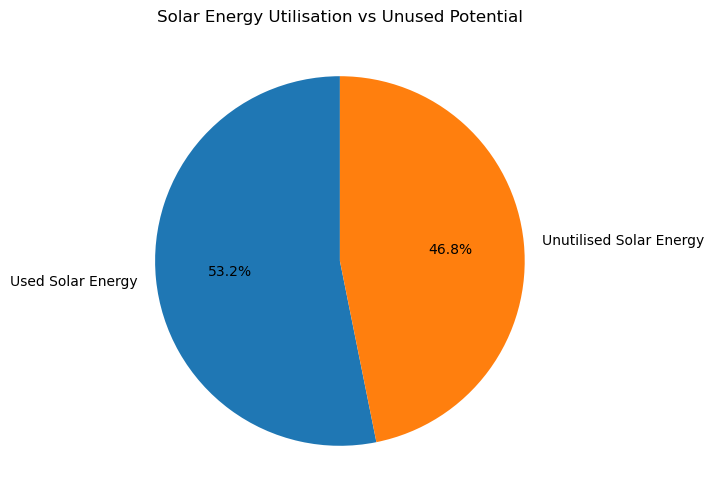

In [48]:
import matplotlib.pyplot as plt

# Recompute safely (no dependency on earlier cells)
curtailment = (merged["pv_potential_kw"] - merged["pv_actual"]).clip(lower=0)

total_potential = merged["pv_potential_kw"].sum()
total_actual = merged["pv_actual"].sum()
total_wasted = curtailment.sum()

utilised_pct = (total_actual / total_potential) * 100 if total_potential > 0 else 0
wasted_pct = (total_wasted / total_potential) * 100 if total_potential > 0 else 0

# =========================================================
# SIMPLE PIE CHART (EXECUTIVE LEVEL)
# =========================================================

labels = ["Used Solar Energy", "Unutilised Solar Energy"]
values = [utilised_pct, wasted_pct]

plt.figure(figsize=(6,6))

plt.pie(
    values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Solar Energy Utilisation vs Unused Potential")
plt.show()

In [44]:
# =========================================================
# 16. SIMPLE ENERGY WASTE KPI (NON-TECHNICAL OUTPUT)
# =========================================================

total_potential_energy = merged["pv_potential_kw"].sum()
total_actual_energy = merged["pv_actual"].sum()

total_unused_energy = merged["curtailment_kw"].sum()

# Safety check (avoid division errors)
if total_potential_energy > 0:
    wasted_energy_pct = (total_unused_energy / total_potential_energy) * 100
    utilised_energy_pct = (total_actual_energy / total_potential_energy) * 100
else:
    wasted_energy_pct = 0
    utilised_energy_pct = 0

print("\n================ SIMPLE ENERGY SUMMARY ================")
print(f"Total Solar Energy Available (Potential): {total_potential_energy:,.2f} kWh")
print(f"Total Solar Energy Used (Actual):        {total_actual_energy:,.2f} kWh")
print(f"Total Solar Energy Wasted (Curtailment): {total_unused_energy:,.2f} kWh")

print("\n--- SIMPLE KPI (FOR NON-TECHNICAL AUDIENCE) ---")
print(f"✔ Energy Utilised: {utilised_energy_pct:.1f}%")
print(f"✖ Energy Wasted:   {wasted_energy_pct:.1f}%")
print("======================================================")

KeyError: 'curtailment_kw'

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. ENSURE DATETIME
# =========================================================

ninja_df["local_time"] = pd.to_datetime(ninja_df["local_time"])
system_hourly["date"] = pd.to_datetime(system_hourly["date"])

# =========================================================
# 2. OPTIONAL: HOURLY ALIGNMENT (SAFE EVEN IF ALREADY HOURLY)
# =========================================================

ninja_hourly = (
    ninja_df
    .set_index("local_time")
    .resample("1h")
    .mean()
    .reset_index()
)

system_hourly = (
    system_hourly
    .set_index("date")
    .resample("1h")
    .mean()
    .reset_index()
)

# =========================================================
# 3. MERGE
# =========================================================

merged = pd.merge(
    system_hourly,
    ninja_hourly,
    left_on="date",
    right_on="local_time",
    how="inner"
)

# =========================================================
# 4. CURTAILMENT CALCULATION
# =========================================================

merged["pv_potential"] = merged["electricity"]
merged["pv_actual"] = merged["pv_actual"]

merged["curtailment"] = merged["pv_potential"] - merged["pv_actual"]
merged["curtailment"] = merged["curtailment"].clip(lower=0)

merged["utilised"] = merged["pv_actual"].clip(lower=0)

# percentage curtailment
merged["curtailment_pct"] = np.where(
    merged["pv_potential"] > 0,
    (merged["curtailment"] / merged["pv_potential"]) * 100,
    0
)

# =========================================================
# 5. TOTAL ENERGY BALANCE
# =========================================================

total_potential = merged["pv_potential"].sum()
total_utilised = merged["utilised"].sum()
total_curtailment = merged["curtailment"].sum()

overall_curtailment_pct = (total_curtailment / total_potential) * 100

print("===== ENERGY SUMMARY =====")
print(f"Total PV Potential  : {total_potential:.2f}")
print(f"Total PV Utilised   : {total_utilised:.2f}")
print(f"Total Curtailment   : {total_curtailment:.2f}")
print(f"Overall Curtailment : {overall_curtailment_pct:.2f}%")

# =========================================================
# 6. PLOT 1: PV POTENTIAL vs ACTUAL
# =========================================================

plt.figure(figsize=(12,4))

plt.plot(merged["date"], merged["pv_potential"], label="PV Potential (Ninja)")
plt.plot(merged["date"], merged["pv_actual"], label="PV Actual (System)")

plt.title("PV Potential vs Actual Generation")
plt.xlabel("Time")
plt.ylabel("Power (kW)")
plt.grid()
plt.legend()

plt.show()

# =========================================================
# 7. PLOT 2: CURTAILMENT OVER TIME
# =========================================================

plt.figure(figsize=(12,4))

plt.plot(merged["date"], merged["curtailment"], label="Curtailment (kW)")

plt.title("Energy Curtailment Over Time")
plt.xlabel("Time")
plt.ylabel("kW")
plt.grid()
plt.legend()

plt.show()

# =========================================================
# 8. PLOT 3: CURTAILMENT %
# =========================================================

plt.figure(figsize=(12,4))

plt.plot(merged["date"], merged["curtailment_pct"], label="Curtailment %")

plt.title("Curtailment Percentage Over Time")
plt.xlabel("Time")
plt.ylabel("%")
plt.grid()
plt.legend()

plt.show()

# =========================================================
# 9. EXPORT
# =========================================================

merged.to_csv("curtailment_results.csv", index=False)
print("Saved: curtailment_results.csv")

KeyError: 'electricity'

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. DATETIME CLEANING
# =========================================================

ninja_df["time"] = pd.to_datetime(ninja_df["time"], utc=True)
system_hourly["date"] = pd.to_datetime(system_hourly["date"])

# Convert Ninja to local time (adjust if needed: Africa/Lagos or Africa/Dar_es_Salaam)
ninja_df["time_local"] = ninja_df["time"].dt.tz_convert("Africa/Lagos")

# =========================================================
# 2. HOURLY ALIGNMENT (SAFE)
# =========================================================

ninja_hourly = (
    ninja_df
    .set_index("time_local")
    .resample("1H")
    .mean()
    .reset_index()
)

system_hourly = (
    system_hourly
    .set_index("date")
    .resample("1H")
    .mean()
    .reset_index()
)

# =========================================================
# 3. MERGE DATASETS
# =========================================================

merged = pd.merge(
    system_hourly,
    ninja_hourly,
    left_on="date",
    right_on="time_local",
    how="inner"
)

# =========================================================
# 4. CURTAILMENT CALCULATION
# =========================================================

merged["curtailment"] = merged["pv_potential_raw"] - merged["pv_actual"]
merged["curtailment"] = merged["curtailment"].clip(lower=0)

merged["utilised_pv"] = merged["pv_actual"].clip(lower=0)

# avoid divide-by-zero
merged["curtailment_pct"] = np.where(
    merged["pv_potential_raw"] > 0,
    (merged["curtailment"] / merged["pv_potential_raw"]) * 100,
    0
)

# =========================================================
# 5. SYSTEM-WIDE METRICS
# =========================================================

total_potential = merged["pv_potential_raw"].sum()
total_utilised = merged["utilised_pv"].sum()
total_curtailment = merged["curtailment"].sum()

overall_curtailment_pct = (total_curtailment / total_potential) * 100

print("\n===== ENERGY SUMMARY =====")
print(f"Total PV Potential   : {total_potential:.2f}")
print(f"Total PV Utilised    : {total_utilised:.2f}")
print(f"Total Curtailment    : {total_curtailment:.2f}")
print(f"Overall Curtailment  : {overall_curtailment_pct:.2f}%")

# =========================================================
# 6. PLOT 1 — POWER TIME SERIES
# =========================================================

plt.figure(figsize=(12,4))

plt.plot(merged["date"], merged["pv_potential_raw"], label="PV Potential (Ninja)")
plt.plot(merged["date"], merged["pv_actual"], label="PV Actual (System)")

plt.title("PV Potential vs Actual Generation")
plt.xlabel("Time")
plt.ylabel("Power (kW)")
plt.grid()
plt.legend()

plt.show()

# =========================================================
# 7. PLOT 2 — CURTAILMENT OVER TIME
# =========================================================

plt.figure(figsize=(12,4))

plt.plot(merged["date"], merged["curtailment"], label="Curtailment (kW)")

plt.title("PV Curtailment Over Time")
plt.xlabel("Time")
plt.ylabel("Power (kW)")
plt.grid()
plt.legend()

plt.show()

# =========================================================
# 8. PLOT 3 — CURTAILMENT %
# =========================================================

plt.figure(figsize=(12,4))

plt.plot(merged["date"], merged["curtailment_pct"], label="Curtailment (%)")

plt.title("PV Curtailment Percentage Over Time")
plt.xlabel("Time")
plt.ylabel("%")
plt.grid()
plt.legend()

plt.show()

# =========================================================
# 9. EXPORT RESULTS
# =========================================================

merged.to_csv("pv_curtailment_analysis.csv", index=False)

print("\nSaved: pv_curtailment_analysis.csv")

/var/folders/g3/t0kvm7d92yz4d6h3xvq1x1bw0000gn/T/ipykernel_26085/3049219713.py:22: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H")
/var/folders/g3/t0kvm7d92yz4d6h3xvq1x1bw0000gn/T/ipykernel_26085/3049219713.py:30: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H")


ValueError: You are trying to merge on datetime64[ns] and datetime64[ns, Africa/Lagos] columns for key 'date'. If you wish to proceed you should use pd.concat